# Bash Scripting Questions

## Task 1: File Management Script

## Write a Bash script that:
### - Creates a directory named "backup" in the user's home directory.
### - Copies all .txt files from the current directory into the "backup" directory.
###- Appends the current date and time to the filenames of the copied files.

```bash
#!/bin/bash

# Task 1: File Management Script

# Step 1: Create a directory named "backup" in the user's home directory
backup_dir="$HOME/backup"
mkdir -p "$backup_dir"

# Step 2: Get the current date and time in YYYY-MM-DD_HH-MM-SS format
timestamp=$(date +"%Y-%m-%d_%H-%M-%S")

# Step 3: Copy all .txt files from the current directory into the "backup" directory
# and append the current date and time to each filename
for file in *.txt; do
    if [ -f "$file" ]; then
        base_name=$(basename "$file" .txt)
        cp "$file" "$backup_dir/${base_name}_${timestamp}.txt"
    fi
done

echo "✅ Backup completed successfully!"
echo "All .txt files copied to $backup_dir with timestamp $timestamp"

```
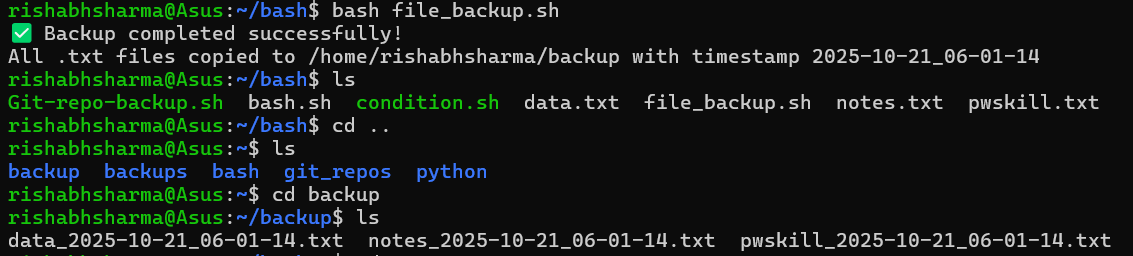

## Task 2: System Health Check

## Create a script that.
###- Checks the system’s CPU and memory usage.
### - Reports if the CPU usage is above 80% or if the available memory is below 20%.
### - Logs the results to a file named system_health.log.

```bash
#!/bin/bash

# Task 2: System Health Check

# Log file
log_file="system_health.log"

# Get timestamp
timestamp=$(date +"%Y-%m-%d %H:%M:%S")

# Get CPU usage (user + system)
cpu_usage=$(top -bn1 | grep "Cpu(s)" | awk '{print 100 - $8}')  # 100 - idle%

# Get memory usage details
mem_total=$(free -m | awk '/Mem:/ {print $2}')
mem_used=$(free -m | awk '/Mem:/ {print $3}')
mem_usage_percent=$(( 100 * mem_used / mem_total ))

# Initialize status message
status="System is healthy."

# Check CPU usage > 80%
if (( $(echo "$cpu_usage > 80" | bc -l) )); then
    status=" High CPU usage detected: ${cpu_usage}%"
fi

# Check if available memory < 20%
if (( mem_usage_percent > 80 )); then
    status=" Low memory available: ${mem_usage_percent}% used"
fi

# Log results
echo "[$timestamp] CPU Usage: ${cpu_usage}% | Memory Usage: ${mem_usage_percent}% | Status: $status" >> "$log_file"

# Display summary
echo " System health checked. Log written to $log_file"

```
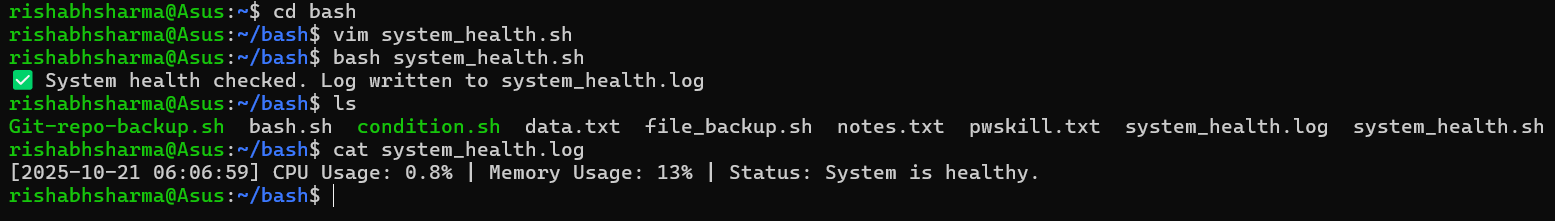

## Task 3: User Account Management

## Write a script that:

### - Reads a list of usernames from a file (e.g., user_list.txt).
### - Creates a new user for each username.
### - Generates a random password for each user and saves the username and password to a file named credentials.txt.

```bash
#!/bin/bash

USER_FILE="user_list.txt"
OUTPUT_FILE="credentials.txt"

if [ ! -f "$USER_FILE" ]; then
    echo "Error: $USER_FILE not found!"
    exit 1
fi

> "$OUTPUT_FILE"

while read -r username; do
    [ -z "$username" ] && continue

    if id "$username" &>/dev/null; then
        echo "User '$username' already exists, skipping..."
        continue
    fi

    sudo useradd -m "$username"
    password=$(openssl rand -base64 12)
    echo "$username:$password" | sudo chpasswd
    echo "Username: $username | Password: $password" >> "$OUTPUT_FILE"
    echo "User '$username' created successfully."
done < "$USER_FILE"

echo "All users processed. Credentials saved in '$OUTPUT_FILE'."

```
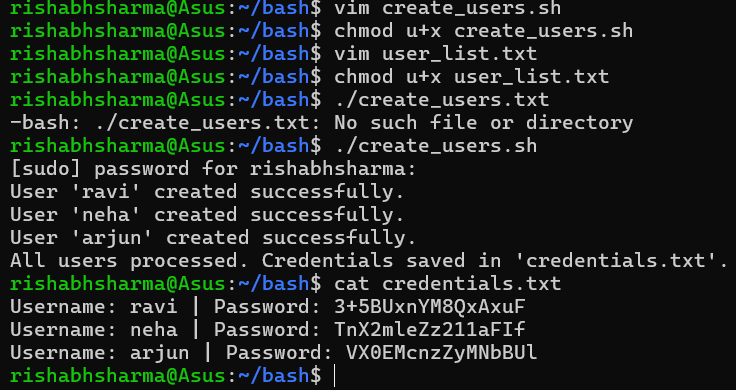


## Task 4: Automated Backup

## Create a script that-

### - Takes a directory path as input from the user.
### - Compresses the directory into a .tar.gz file.
### - Saves the compressed file with a name that includes the current date (eg., backup_2023-08-20.tar.gz).

```bash
#!/bin/bash

read -p "Enter the full path of the directory to back up: " dir_path

if [ ! -d "$dir_path" ]; then
    echo "Error: Directory '$dir_path' does not exist."
    exit 1
fi

backup_dir="$HOME/backups"
mkdir -p "$backup_dir"

current_date=$(date +%F)
backup_file="$backup_dir/backup_${current_date}.tar.gz"

tar -czf "$backup_file" -C "$(dirname "$dir_path")" "$(basename "$dir_path")"

if [ $? -eq 0 ]; then
    echo "Backup created successfully: $backup_file"
else
    echo "Backup failed."
    exit 1
fi
```
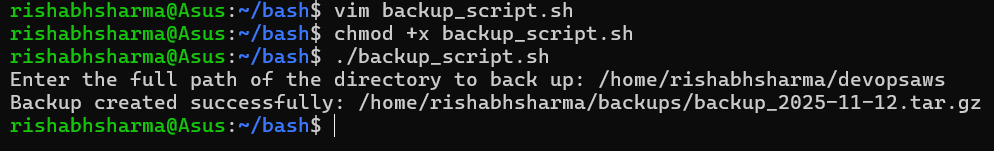

## Task 5: Simple To-Do List

## Create a Bash script that:
- Implements a simple command-line to-do list.
- Allows the user to add tasks, view tasks, and remove tasks.
- Saves the tasks to a file (e.g., todo.txt).

```bash
#!/bin/bash

TODO_FILE="todo.txt"

# Create file if it doesn't exist
if [ ! -f "$TODO_FILE" ]; then
    touch "$TODO_FILE"
fi

show_menu() {
    echo "==========================="
    echo "       TO-DO LIST"
    echo "==========================="
    echo "1. View Tasks"
    echo "2. Add Task"
    echo "3. Remove Task"
    echo "4. Exit"
    echo -n "Choose an option: "
}

view_tasks() {
    if [ ! -s "$TODO_FILE" ]; then
        echo "No tasks found!"
    else
        echo "Your Tasks:"
        nl -w2 -s'. ' "$TODO_FILE"
    fi
}

add_task() {
    echo -n "Enter task: "
    read task
    echo "$task" >> "$TODO_FILE"
    echo "Task added!"
}

remove_task() {
    view_tasks
    echo -n "Enter task number to remove: "
    read num

    sed -i "${num}d" "$TODO_FILE"
    echo "Task removed!"
}

while true; do
    show_menu
    read choice

    case $choice in
        1) view_tasks ;;
        2) add_task ;;
        3) remove_task ;;
        4) echo "Goodbye!"; exit ;;
        *) echo "Invalid choice! Try again." ;;
    esac

    echo ""
done

```
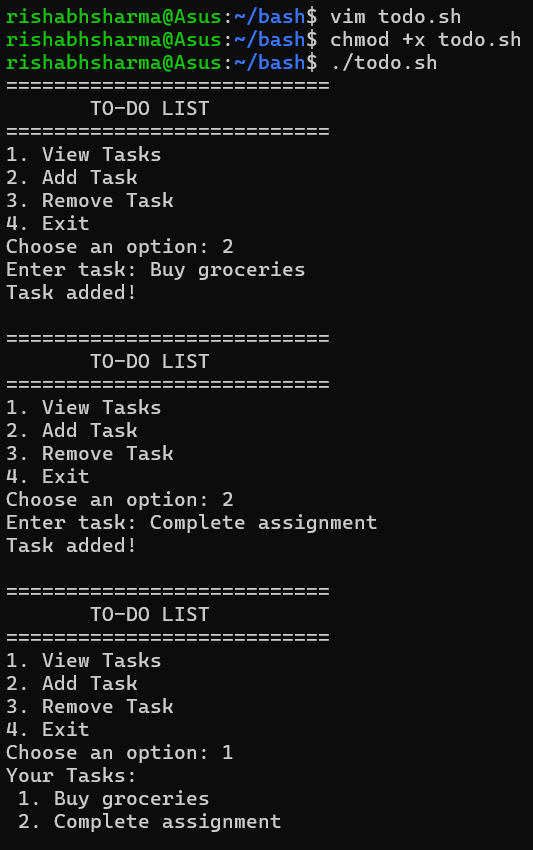
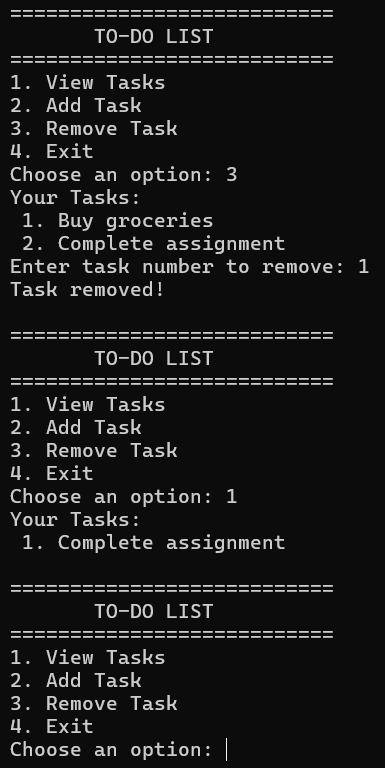

## Task 6: Automated Software Installation

## Write a script that:
- Reads a list of software package names from a file (e.g., packages.txt).
- Installs each package using the appropriate package manager (apt, yum, etc.).
- Logs the installation status of each package.

```bash
#!/bin/bash

PACKAGE_FILE="packages.txt"
LOG_FILE="install.log"

# Detect package manager
if command -v apt >/dev/null 2>&1; then
    PM="apt"
elif command -v yum >/dev/null 2>&1; then
    PM="yum"
elif command -v dnf >/dev/null 2>&1; then
    PM="dnf"
else
    echo "No supported package manager found!"
    exit 1
fi

echo "Using package manager: $PM"
echo "------ Installation Log ------" > "$LOG_FILE"

# Read package names and install
while IFS= read -r package
do
    if [ -z "$package" ]; then
        continue
    fi

    echo "Installing: $package"
    echo "Installing: $package" >> "$LOG_FILE"

    if sudo $PM install -y "$package" >> "$LOG_FILE" 2>&1; then
        echo "SUCCESS: $package installed." >> "$LOG_FILE"
    else
        echo "FAILED: $package installation failed." >> "$LOG_FILE"
    fi

done < "$PACKAGE_FILE"

echo "Installation completed. Check install.log for details."

```

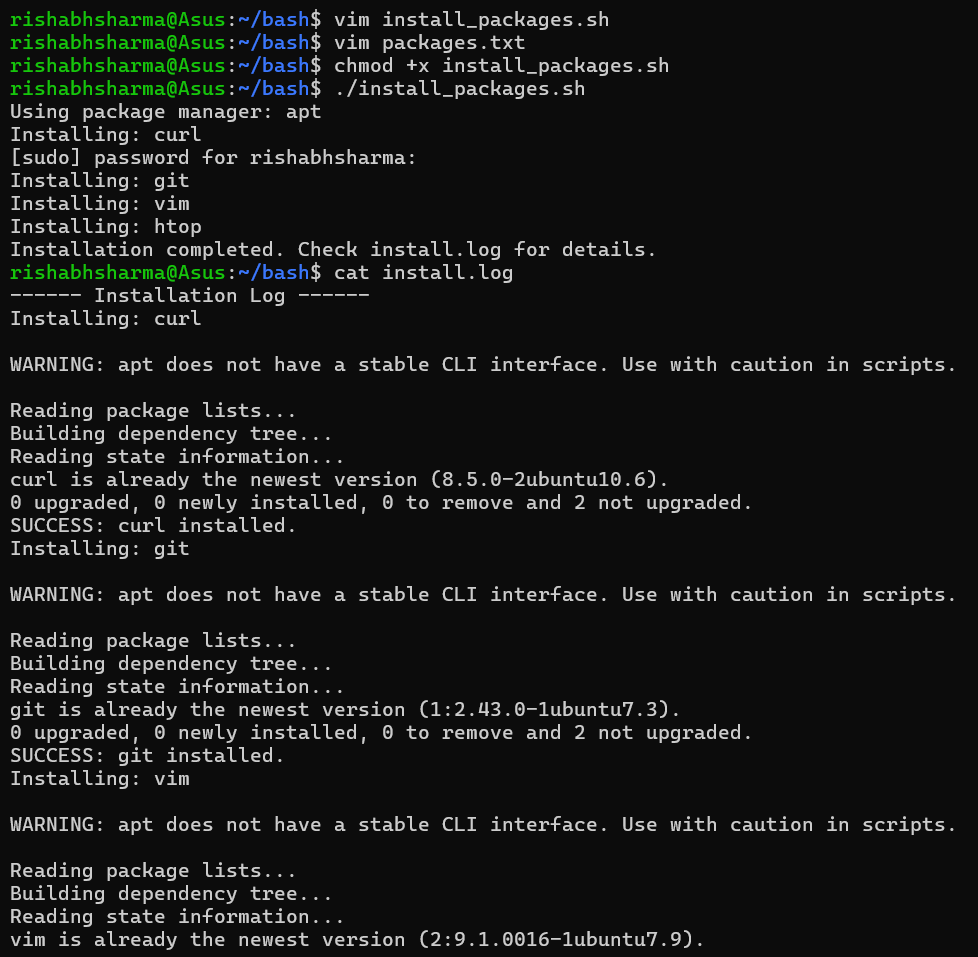

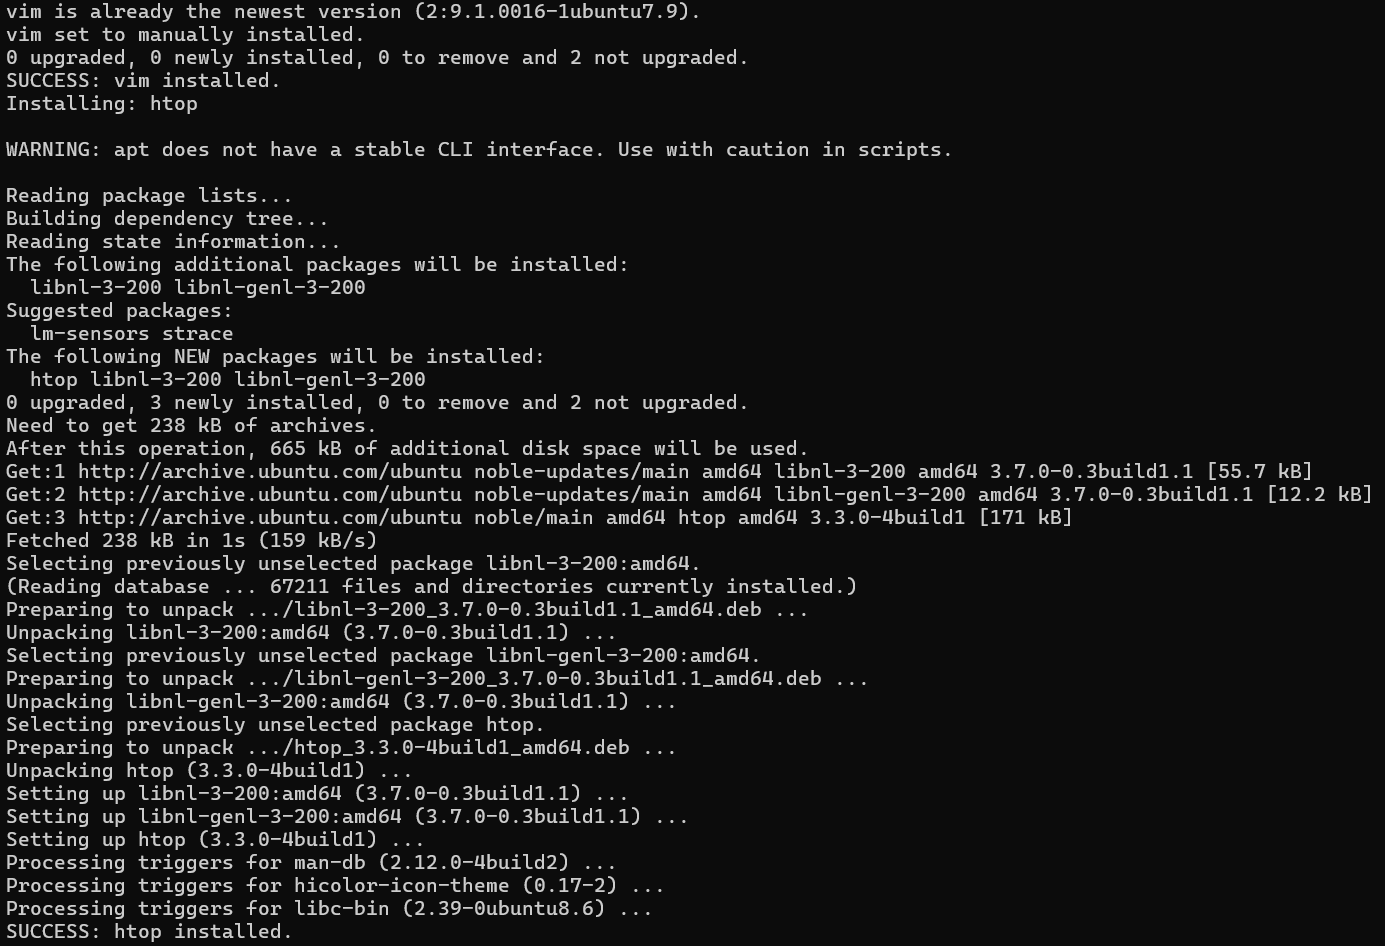

## Task 7: Text File Processing

## Create a script that:
- Takes a text file as input.
- Counts and displays the number of lines, words, and characters in the file.
- Finds and displays the longest word in the file.


```bash
#!/bin/bash

if [ -z "$1" ]; then
    echo "Usage: ./text_stats.sh <filename>"
    exit 1
fi

FILE="$1"

if [ ! -f "$FILE" ]; then
    echo "File not found!"
    exit 1
fi

lines=$(wc -l < "$FILE")
words=$(wc -w < "$FILE")
chars=$(wc -m < "$FILE")

longest_word=$(tr ' ' '\n' < "$FILE" | tr -d '[:punct:]' | \
awk '{ if (length > max) { max = length; word = $0 } } END { print word }')

echo "File: $FILE"
echo "-------------------------"
echo "Lines: $lines"
echo "Words: $words"
echo "Characters: $chars"
echo "Longest word: $longest_word"

```
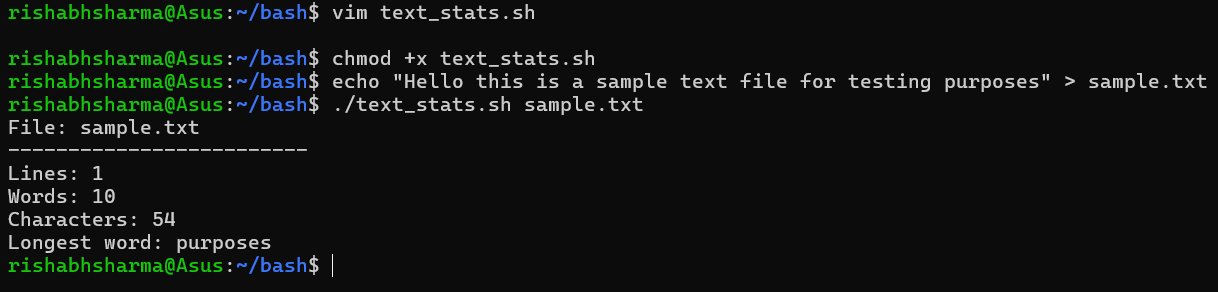